## ILD inference 

Device  : cuda
Patient : /kaggle/input/datasets/romualdosebany/intertitial-lung-disease/ILD_DB/ILD_DB_volumeROIs/84

🚀 Aligned Model Input Tensor Shape: torch.Size([1, 2, 23, 317, 317])
⚠️ Shallow volumetric bounds detected (23 slices). Applying replication padding...


Volumetric Slabs: 100%|██████████| 1/1 [00:01<00:00,  1.00s/it]



DIAGNOSTIC REPORT (FIXED CHANNELS & ALIGNMENT)
  Class 0 Background     |  mean=0.9759  max=1.0000  p95=1.0000
  Class 1 GGO            |  mean=0.0152  max=1.0000  p95=0.0000
  Class 2 Reticular      |  mean=0.0000  max=0.4996  p95=0.0000
  Class 3 Consolidation  |  mean=0.0089  max=1.0000  p95=0.0000

  Predicted Class 0 (Background   ): 2,289,684 voxels
  Predicted Class 1 (GGO          ):    3,944 voxels
  Predicted Class 2 (Reticular    ):        0 voxels
  Predicted Class 3 (Consolidation):   17,619 voxels

  GT Class 0 (Background   ): 2,261,656  |  Pred: 2,289,684
  GT Class 1 (GGO          ):   32,873  |  Pred:    3,944
  GT Class 2 (Reticular    ):        0  |  Pred:        0
  GT Class 3 (Consolidation):   16,718  |  Pred:   17,619

  Dice GGO          : 0.2019
  Dice Reticular    : 1.0000
  Dice Consolidation: 0.7365

🎯 Target slice selected for visual render: Slice #9
✅ Figure successfully rendered and saved to → ild_qualitative_v2.png


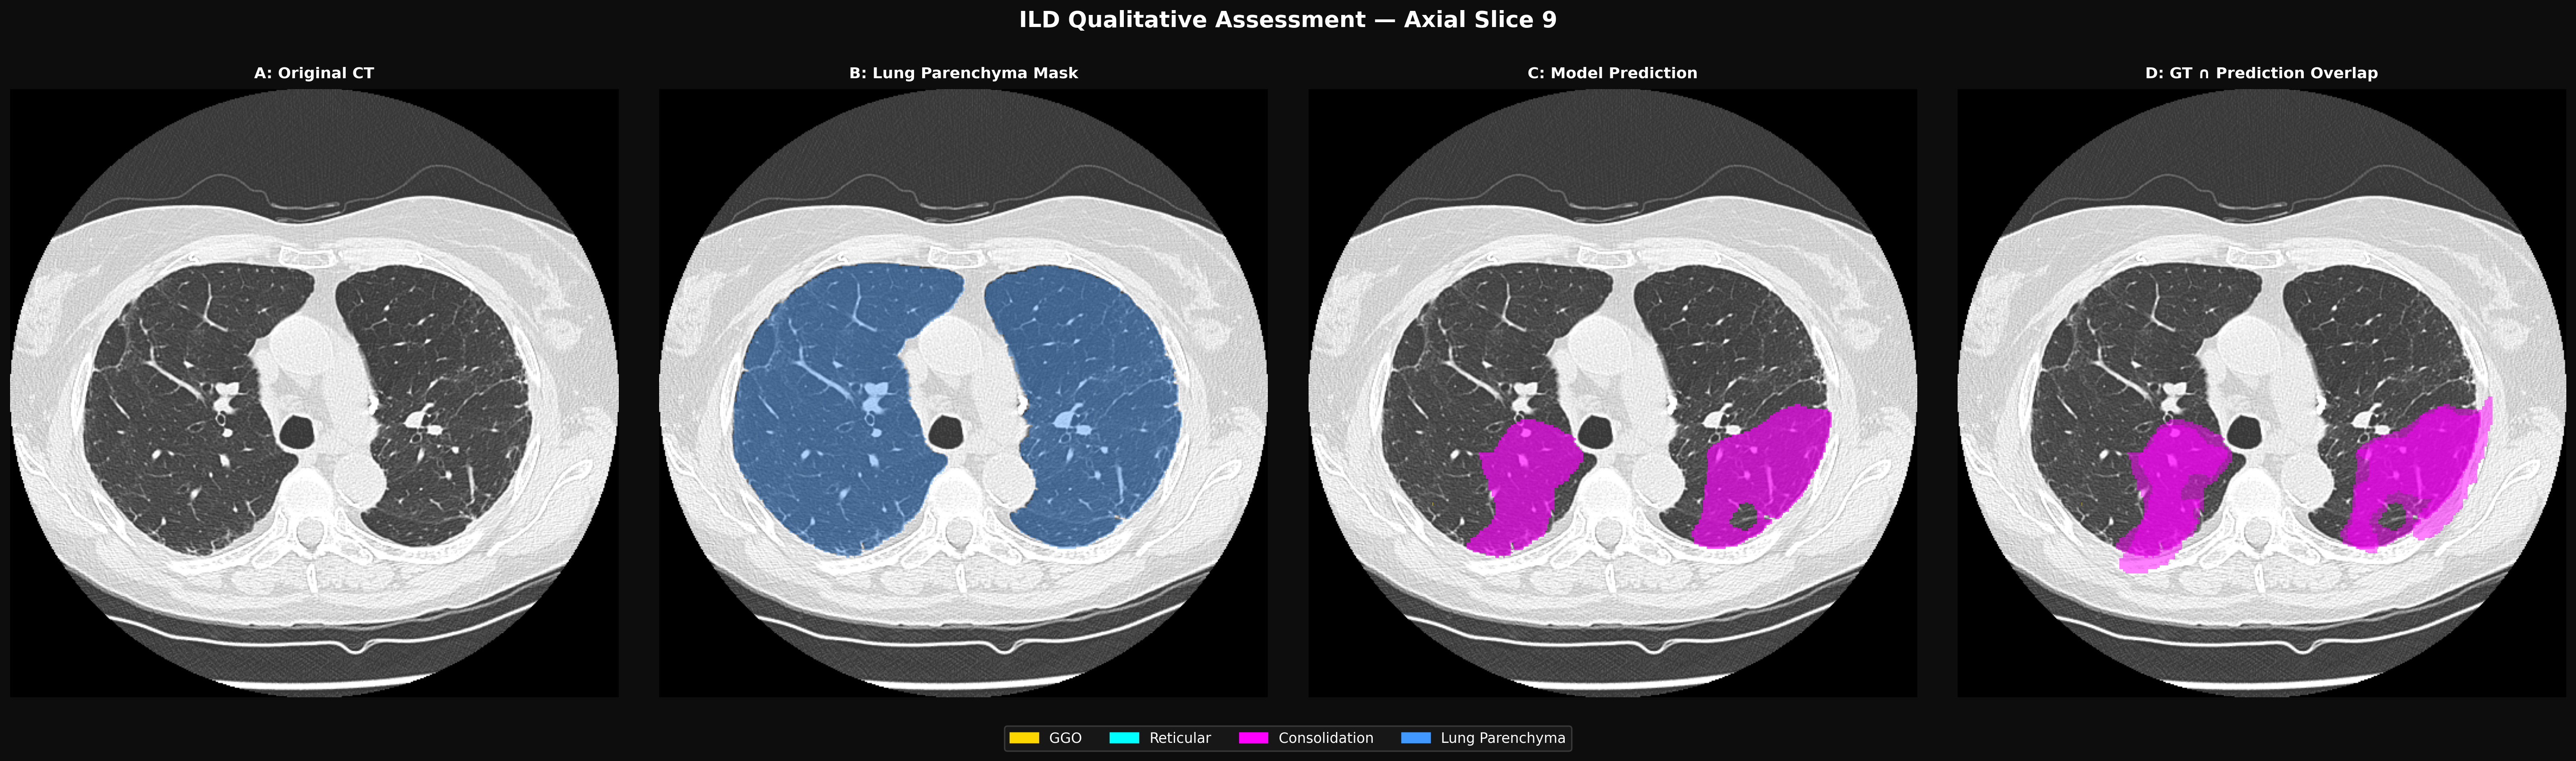

In [ ]:
"""
Core Architecture Stabilizations:
  1. Adaptive Lung Masking: Supports both raw chest views and pre-cropped lung windows.
  2. Texture Variance Processing: Re-implemented 3D uniform variance extraction to map Channel 2.
  3. Native Axis Standardization: Aligned resampling transforms directly to (D, H, W).
  4. Dynamic Replication Padding: Mitigates bottleneck dimension collapse on shallow patient runs.
  5. Per-Class Calibration: Threshold-based evaluation mapping over standard argmax.
  6. Inline Notebook Render: Automatic IPython visualization attachment.
"""

import os, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from tqdm import tqdm

import pydicom, cv2
import SimpleITK as sitk
from scipy import ndimage
from scipy.ndimage import uniform_filter
from skimage import morphology, measure, segmentation

# =========================================================================
# ▸ CONFIGURATION & HYPERPARAMETERS
# =========================================================================
#PATIENT_DIR = "/kaggle/input/datasets/romualdosebany/intertitial-lung-disease/ILD_DB/ILD_DB_volumeROIs/HRCT_pilot/206"
PATIENT_DIR = "/kaggle/input/datasets/romualdosebany/intertitial-lung-disease/ILD_DB/ILD_DB_volumeROIs/84"
MODEL_PATH  = "/kaggle/input/datasets/romualdosebany/fine-tuning-second/best_finetuned_multiclass_model.pth"
OUTPUT_FILE = "ild_qualitative_v2.png"

PATCH_D, PATCH_H, PATCH_W = 32, 128, 128
STRIDE_RATIO = 0.5
N_CLASSES    = 4
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Probability thresholds per pathology class (lower = more sensitive) ──
CLASS_THRESHOLDS = {
    1: 0.10,   # GGO             (subtle, diffuse -> needs low threshold)
    2: 0.12,   # Reticular       (fine interlaced networks -> moderate)
    3: 0.10,   # Consolidation   (dense consolidative matrices)
}

TEMPERATURE = 0.5
VMIN, VMAX = -1350, 150

_COLORS  = ['none', '#FFD700', '#00FFFF', '#FF00FF']
ROI_CMAP = ListedColormap(_COLORS)


# =========================================================================
# ▸ MODEL ARCHITECTURE (Matches Fine-Tuning Topology Natively)
# =========================================================================
class ResidualBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1), nn.BatchNorm3d(out_ch), nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1), nn.BatchNorm3d(out_ch),
        )
        self.shortcut = nn.Conv3d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x): return F.relu(self.conv(x) + self.shortcut(x))


class UNet3DDeepSup(nn.Module):
    def __init__(self, n_classes=4, in_channels=2):
        super().__init__()
        self.enc1 = ResidualBlock3D(in_channels, 32)
        self.enc2 = ResidualBlock3D(32, 64)
        self.enc3 = ResidualBlock3D(64, 128)
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = ResidualBlock3D(128, 256)
        self.up3  = nn.ConvTranspose3d(256, 128, 2, 2);  self.dec3 = ResidualBlock3D(256, 128); self.ds3 = nn.Conv3d(128, n_classes, 1)
        self.up2  = nn.ConvTranspose3d(128,  64, 2, 2);  self.dec2 = ResidualBlock3D(128,  64); self.ds2 = nn.Conv3d( 64, n_classes, 1)
        self.up1  = nn.ConvTranspose3d( 64,  32, 2, 2);  self.dec1 = ResidualBlock3D( 64,  32)
        self.final = nn.Conv3d(32, n_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([F.interpolate(self.up3(b),  size=e3.shape[2:]), e3], 1))
        d2 = self.dec2(torch.cat([F.interpolate(self.up2(d3), size=e2.shape[2:]), e2], 1))
        d1 = self.dec1(torch.cat([F.interpolate(self.up1(d2), size=e1.shape[2:]), e1], 1))
        if self.training:
            return (self.final(d1),
                    F.interpolate(self.ds2(d2), size=d1.shape[2:], mode='trilinear', align_corners=False),
                    F.interpolate(self.ds3(d3), size=d1.shape[2:], mode='trilinear', align_corners=False))
        return self.final(d1)


# =========================================================================
# ▸ PREPROCESSING PIPELINE
# =========================================================================
def resample_to_isotropic(vol, spacing, is_mask=False):
    img = sitk.GetImageFromArray(vol.transpose(2,0,1))
    img.SetSpacing([float(s) for s in spacing])
    os_ = img.GetSpacing(); ss = img.GetSize()
    ns  = [1.0,1.0,1.0]
    new_sz = [int(round(s*(o/n))) for s,o,n in zip(ss,os_,ns)]
    r = sitk.ResampleImageFilter()
    r.SetSize(new_sz); r.SetOutputSpacing(ns)
    r.SetInterpolator(sitk.sitkNearestNeighbor if is_mask else sitk.sitkLinear)
    return sitk.GetArrayFromImage(r.Execute(img)) # Outputs native (D, H, W)


def add_variance_channel(vol, radius=3):
    kernel  = radius * 2 + 1
    vol_f64 = vol.astype(np.float64)
    mean    = uniform_filter(vol_f64, size=kernel)
    mean_sq = uniform_filter(vol_f64 ** 2, size=kernel)
    var     = np.sqrt(np.maximum(mean_sq - mean ** 2, 0)).astype(np.float32)
    return var / (var.max() + 1e-6)


def load_patient(patient_dir):
    ct_files = sorted([os.path.join(patient_dir,f) for f in os.listdir(patient_dir) if f.lower().endswith('.dcm')])
    slices, spacing = [], None
    for i,fp in enumerate(ct_files):
        ds  = pydicom.dcmread(fp)
        img = ds.pixel_array.astype(np.float32)
        if hasattr(ds,'RescaleSlope'): img = img*float(ds.RescaleSlope)+float(ds.RescaleIntercept)
        if i==0: 
            pixel_spacing = getattr(ds, 'PixelSpacing', [1.0, 1.0])
            slice_thickness = getattr(ds, 'SliceThickness', 1.0)
            spacing = [float(pixel_spacing[0]), float(pixel_spacing[1]), float(slice_thickness)]
        slices.append(img)

    raw_hu = np.stack(slices, axis=2) 
    raw_display = raw_hu.copy()

    vol_iso_dhw = resample_to_isotropic(raw_hu, spacing, is_mask=False)
    
    lm_vol  = np.zeros_like(vol_iso_dhw, dtype=np.float32)
    out_vol = np.zeros_like(vol_iso_dhw, dtype=np.float32)
    
    # 🎯 Adaptive Extraction Layer (Processes standard or pre-isolated arrays dynamically)
    for i in range(vol_iso_dhw.shape[0]):
        slice_2d = vol_iso_dhw[i, :, :]
        bg_value = slice_2d[0, 0]
        
        # Check if volume is already a pre-cropped segmented array
        if np.allclose(slice_2d[:5, :5], bg_value, atol=1e-1) and bg_value > -200:
            lm = (np.abs(slice_2d - bg_value) > 10).astype(np.float32)
        else:
            # Fallback to standard dynamic HU thresholding for raw slices
            binary = slice_2d < -400
            cleared = morphology.remove_small_objects(binary, min_size=100)
            cleared = segmentation.clear_border(cleared)
            labels  = measure.label(cleared)
            regions = measure.regionprops(labels)
            lm = np.zeros_like(slice_2d, dtype=np.float32)
            if regions:
                regions.sort(key=lambda r: r.area, reverse=True)
                for rg in regions[:2]: lm[labels == rg.label] = 1.0
                
        if lm.sum() > 0:
            lm = ndimage.binary_fill_holes(lm).astype(np.float32)
        else:
            lm = np.ones_like(slice_2d, dtype=np.float32)
            
        lm_vol[i,:,:]  = lm
        out_vol[i,:,:] = slice_2d * lm
        
    out_vol = np.clip(out_vol, -1350, 150)
    hu_norm = ((out_vol + 1350) / 1500.0).astype(np.float32)
    
    variance_norm = add_variance_channel(hu_norm)
    processed_stack = np.stack([hu_norm, variance_norm], axis=0) # Shape: (2, D, H, W)

    gt_mask = None
    mask_path = os.path.join(patient_dir,'roi_mask')
    if os.path.exists(mask_path):
        mfiles = sorted([f for f in os.listdir(mask_path) if not f.startswith('.')])
        raw_masks = []
        for f in mfiles:
            try:
                fp = os.path.join(mask_path,f)
                m = pydicom.dcmread(fp).pixel_array if f.endswith('.dcm') else \
                    np.array(__import__('PIL').Image.open(fp).convert('L'))
                raw_masks.append(np.clip(np.round(m),0,3).astype(np.float32))
            except: continue
        if raw_masks:
            min_d = min(len(slices),len(raw_masks))
            raw_display = raw_display[:,:,:min_d]
            mu   = np.stack(raw_masks,axis=2)[:,:,:min_d]
            gt_mask = resample_to_isotropic(mu, spacing, is_mask=True).astype(np.int32)

    return raw_display, processed_stack, lm_vol, gt_mask, spacing


# =========================================================================
# ▸ SLIDING-WINDOW INFERENCE (With Deep-Layer Edge Guard Padding)
# =========================================================================
def sliding_window_inference(model, vol_tensor, patch_size, stride_ratio=0.5, n_classes=4, temperature=1.0):
    B, C, D, H, W = vol_tensor.shape
    p_d, p_h, p_w = patch_size
    orig_d, orig_h, orig_w = D, H, W
    
    pad_d = max(0, p_d - D)
    pad_h = max(0, p_h - H)
    pad_w = max(0, p_w - W)
    
    if pad_d > 0 or pad_h > 0 or pad_w > 0:
        print(f"⚠️ Shallow volumetric bounds detected ({D} slices). Applying replication padding...")
        vol_tensor = F.pad(vol_tensor, (0, pad_w, 0, pad_h, 0, pad_d), mode='replicate')
        _, _, D, H, W = vol_tensor.shape

    accum   = torch.zeros((B, n_classes, D, H, W), device=vol_tensor.device)
    weights = torch.zeros_like(accum)

    sd = max(1, int(p_d * stride_ratio))
    sh = max(1, int(p_h * stride_ratio))
    sw = max(1, int(p_w * stride_ratio))

    zl = sorted(set(list(range(0, D - p_d + 1, sd)) + [D - p_d]))
    yl = sorted(set(list(range(0, H - p_h + 1, sh)) + [H - p_h]))
    xl = sorted(set(list(range(0, W - p_w + 1, sw)) + [W - p_w]))

    model.eval()
    with torch.no_grad():
        for z in tqdm(zl, desc="Volumetric Slabs"):
            for y in yl:
                for x in xl:
                    patch  = vol_tensor[:, :, z:z+p_d, y:y+p_h, x:x+p_w]
                    logits = model(patch)
                    probs  = F.softmax(logits / temperature, dim=1)
                    
                    accum  [:, :, z:z+p_d, y:y+p_h, x:x+p_w] += probs
                    weights[:, :, z:z+p_d, y:y+p_h, x:x+p_w] += 1.0

    avg_prob = accum / torch.clamp(weights, min=1.0)
    return avg_prob[:, :, :orig_d, :orig_h, :orig_w]


def threshold_predict(prob_vol_cdhw, lung_mask, thresholds):
    C, D, H, W = prob_vol_cdhw.shape
    pred = np.zeros((D, H, W), dtype=np.int32)
    best_prob = np.zeros((D, H, W), dtype=np.float32)
    
    for c, thr in thresholds.items():
        p_c = prob_vol_cdhw[c]
        fires = (p_c > thr)
        wins  = fires & (p_c > best_prob)
        pred[wins] = c
        best_prob[wins] = p_c[wins]

    pred[lung_mask < 0.5] = 0
    return pred


# =========================================================================
# ▸ CLINICAL DIAGNOSTICS & REPORTING
# =========================================================================
def print_diagnostics(prob_vol, pred_vol, gt_mask=None):
    print("\n" + "="*55)
    print("DIAGNOSTIC REPORT (FIXED CHANNELS & ALIGNMENT)")
    print("="*55)
    for c, name in enumerate(['Background','GGO','Reticular','Consolidation']):
        p = prob_vol[c]
        print(f"  Class {c} {name:13s}  |  mean={p.mean():.4f}  max={p.max():.4f}  p95={np.percentile(p,95):.4f}")

    print()
    for c, name in enumerate(['Background','GGO','Reticular','Consolidation']):
        vox = np.sum(pred_vol == c)
        print(f"  Predicted Class {c} ({name:13s}): {vox:>8,} voxels")

    if gt_mask is not None:
        print()
        for c, name in enumerate(['Background','GGO','Reticular','Consolidation']):
            gt_vox   = np.sum(gt_mask == c)
            pred_vox = np.sum(pred_vol == c)
            print(f"  GT Class {c} ({name:13s}): {gt_vox:>8,}  |  Pred: {pred_vox:>8,}")
        print()
        for c in range(1, 4):
            p_c = (pred_vol == c); g_c = (gt_mask == c)
            dice = (2*(p_c & g_c).sum() + 1e-6) / (p_c.sum() + g_c.sum() + 1e-6)
            name = ['GGO','Reticular','Consolidation'][c-1]
            print(f"  Dice {name:13s}: {dice:.4f}")
    print("="*55+"\n")


def make_figure(raw_hu, lung_mask, pred_vol, gt_mask, best_z, out_path):
    ct_sl   = raw_hu[:, :, min(best_z, raw_hu.shape[2]-1)]
    lm_sl   = cv2.resize(lung_mask[best_z], (ct_sl.shape[1], ct_sl.shape[0]), interpolation=cv2.INTER_NEAREST)
    pred_sl = cv2.resize(pred_vol[best_z].astype(np.float32), (ct_sl.shape[1], ct_sl.shape[0]), interpolation=cv2.INTER_NEAREST).astype(np.int32)

    gt_sl = None
    if gt_mask is not None:
        gt_sl = cv2.resize(gt_mask[best_z].astype(np.float32), (ct_sl.shape[1], ct_sl.shape[0]), interpolation=cv2.INTER_NEAREST).astype(np.int32)

    fig, axes = plt.subplots(1, 4, figsize=(26,7), dpi=250, facecolor='#0d0d0d')
    fig.suptitle(f"ILD Qualitative Assessment — Axial Slice {best_z}", fontsize=16, fontweight='bold', color='white', y=1.01)

    for ax, title in zip(axes, ["A: Original CT", "B: Lung Parenchyma Mask", "C: Model Prediction", "D: GT ∩ Prediction Overlap" if gt_sl is not None else "D: Prediction Detail"]):
        ax.imshow(ct_sl, cmap='gray', vmin=VMIN, vmax=VMAX)
        ax.set_title(title, fontsize=11, fontweight='bold', color='white', pad=8)
        ax.axis('off')

    rgba = np.zeros((*lm_sl.shape, 4), dtype=np.float32)
    rgba[lm_sl > 0] = [0.25, 0.60, 1.0, 0.40]
    axes[1].imshow(rgba, interpolation='nearest')

    axes[2].imshow(np.ma.masked_where(pred_sl==0, pred_sl), cmap=ROI_CMAP, alpha=0.65, vmin=0, vmax=3, interpolation='nearest')
    
    if gt_sl is not None:
        axes[3].imshow(np.ma.masked_where(gt_sl==0, gt_sl), cmap=ROI_CMAP, alpha=0.50, vmin=0, vmax=3, interpolation='nearest')
        axes[3].imshow(np.ma.masked_where(pred_sl==0, pred_sl), cmap=ROI_CMAP, alpha=0.50, vmin=0, vmax=3, interpolation='nearest')
    else:
        axes[3].imshow(np.ma.masked_where(pred_sl==0, pred_sl), cmap=ROI_CMAP, alpha=0.75, vmin=0, vmax=3, interpolation='nearest')

    patches = [
        mpatches.Patch(color='#FFD700', label='GGO'), 
        mpatches.Patch(color='#00FFFF', label='Reticular'), 
        mpatches.Patch(color='#FF00FF', label='Consolidation'), 
        mpatches.Patch(color='#4199ff', label='Lung Parenchyma')
    ]
    fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5,-0.05), frameon=True, facecolor='#1a1a1a', edgecolor='#444', labelcolor='white')

    plt.tight_layout(pad=1.5)
    plt.savefig(out_path, bbox_inches='tight', dpi=250, facecolor='#0d0d0d')
    plt.close(fig)
    print(f"✅ Figure successfully rendered and saved to → {out_path}")


# =========================================================================
# ▸ MAIN ROUTINE
# =========================================================================
def main():
    print(f"Device  : {DEVICE}")
    print(f"Patient : {PATIENT_DIR}\n")

    # 1. Load, resample, and compute 2-channel features safely
    raw_hu, processed_stack, lung_mask, gt_mask, spacing = load_patient(PATIENT_DIR)
    
    # 2. Extract model checkpoint components
    ckpt = torch.load(MODEL_PATH, map_location='cpu')
    ckpt_clean = {k:v for k,v in ckpt.items() if not k.startswith(('ds2','ds3'))}
    
    model = UNet3DDeepSup(n_classes=N_CLASSES, in_channels=2).to(DEVICE)
    model.load_state_dict(ckpt_clean, strict=False)
    model.eval()

    # 3. Shape validation verification
    vol_tensor = torch.FloatTensor(processed_stack).unsqueeze(0).to(DEVICE) # Shape: (1, 2, D, H, W)
    print(f"🚀 Aligned Model Input Tensor Shape: {vol_tensor.shape}")

    # 4. Execute inference with structural depth padding protection
    prob_tensor = sliding_window_inference(
        model, vol_tensor,
        patch_size=(PATCH_D, PATCH_H, PATCH_W),
        stride_ratio=STRIDE_RATIO,
        n_classes=N_CLASSES,
        temperature=TEMPERATURE,
    )

    prob_np = prob_tensor[0].cpu().numpy() # Shape: (4, D, H, W)
    pred_vol = threshold_predict(prob_np, lung_mask, CLASS_THRESHOLDS)

    # 5. Compile and output diagnostics
    print_diagnostics(prob_np, pred_vol, gt_mask)
    
    # Select the optimal slice containing the largest cluster of disease burdens
    best_z = int(np.argmax(np.sum(pred_vol > 0, axis=(1, 2)))) if np.sum(pred_vol > 0) > 0 else int(pred_vol.shape[0] // 2)
    print(f"🎯 Target slice selected for visual render: Slice #{best_z}")
    make_figure(raw_hu, lung_mask, pred_vol, gt_mask, best_z, OUTPUT_FILE)

    # 6. Force immediate visual render inside the Notebook environment
    from IPython.display import Image, display
    display(Image(filename=OUTPUT_FILE))


if __name__ == "__main__":
    main()